# Curva de Precisão-Recall com Dataset Iris

Utilizando **Naive Bayes (GaussianNB)** e recursos nativos do **scikit-learn** para visualização.
Este notebook foi ajustado para funcionar sem `scikit-plot`.


In [13]:
# Importações necessárias
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


In [14]:
iris = datasets.load_iris()

X = iris.data
y = iris.target

print("Shape dos dados:", X.shape)
print("Classes:", iris.target_names)

Shape dos dados: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste: ", X_test.shape)

Tamanho treino: (120, 4)
Tamanho teste:  (30, 4)


In [16]:
NaiveBayesClassificador = GaussianNB()

NaiveBayesClassificador.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


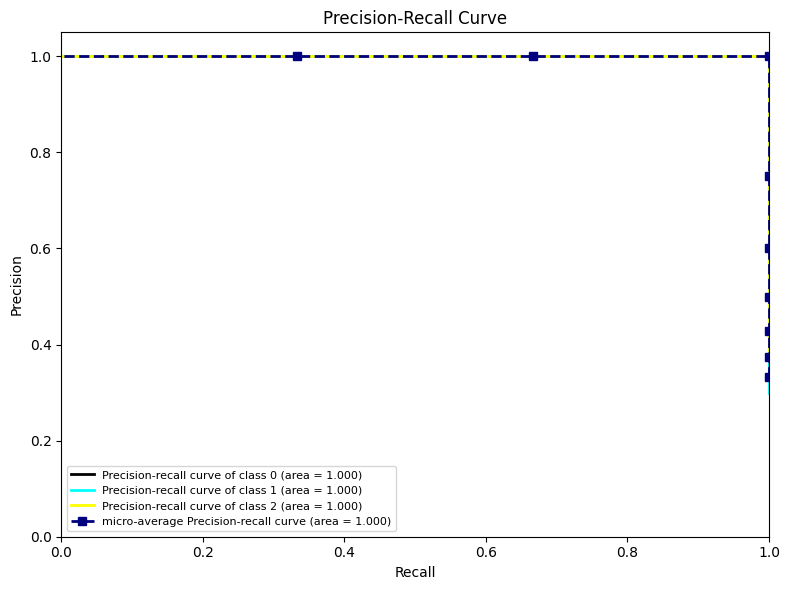

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np

y_probas = NaiveBayesClassificador.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

colors = ['black', 'cyan', 'yellow']
n_classes = 3

precision = {}
recall = {}
avg_precision = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_probas[:, i])
    avg_precision[i] = average_precision_score(y_test_bin[:, i], y_probas[:, i])

# Micro-average
precision['micro'], recall['micro'], _ = precision_recall_curve(
    y_test_bin.ravel(), y_probas.ravel()
)
avg_precision['micro'] = average_precision_score(y_test_bin, y_probas, average='micro')

plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'Precision-recall curve of class {i} (area = {avg_precision[i]:.3f})')

plt.plot(recall['micro'], precision['micro'], color='navy', lw=2, linestyle='--',
         marker='s', markevery=10,
         label=f'micro-average Precision-recall curve (area = {avg_precision["micro"]:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left', fontsize=8)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

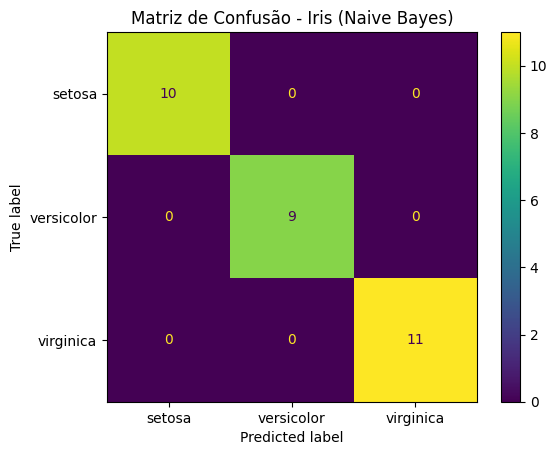

In [18]:
# 8. Previsões e matriz de confusão
y_pred = NaiveBayesClassificador.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names
)
plt.title("Matriz de Confusão - Iris (Naive Bayes)")
plt.show()
